In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import json
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2
from typing import List, Dict, Any

In [2]:
DATASET_DIR = r'D:\Resources\College Stuff\NFT\Mini Project\mapillary-vistas'
IMG_DIR = os.path.join(DATASET_DIR, 'training/img')
MASK_DIR = os.path.join(DATASET_DIR, 'training/mask')
META_PATH = os.path.join(DATASET_DIR, 'meta.json')
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, 'training/img')
TRAIN_MASK_DIR = os.path.join(DATASET_DIR, 'training/mask')
VAL_IMG_DIR = os.path.join(DATASET_DIR, 'validation/img')
VAL_MASK_DIR = os.path.join(DATASET_DIR, 'validation/mask')
REAL_IMGS = r'D:\Resources\College Stuff\NFT\Mini Project\real'
REAL_VIDS = r'D:\Resources\College Stuff\NFT\Mini Project\rvids'

In [3]:
with open(META_PATH) as f:
    meta = json.load(f)

meta_list = [{"title": c["title"], "id": c["id"], "color": c["color"]} for c in meta["classes"]]
print(meta_list)

[{'title': 'bird', 'id': 6479238, 'color': '#A52A2A'}, {'title': 'ground animal', 'id': 6479239, 'color': '#00C000'}, {'title': 'ambiguous barrier', 'id': 6479240, 'color': '#FAAA1F'}, {'title': 'concrete block', 'id': 6479241, 'color': '#FAAA20'}, {'title': 'curb', 'id': 6479242, 'color': '#C4C4C4'}, {'title': 'fence', 'id': 6479243, 'color': '#BE9999'}, {'title': 'guard rail', 'id': 6479244, 'color': '#B4A5B4'}, {'title': 'barrier', 'id': 6479245, 'color': '#5A7896'}, {'title': 'road median', 'id': 6479246, 'color': '#FAAA21'}, {'title': 'road side', 'id': 6479247, 'color': '#FAAA22'}, {'title': 'lane separator', 'id': 6479248, 'color': '#808080'}, {'title': 'temporary barrier', 'id': 6479249, 'color': '#FAAA23'}, {'title': 'wall', 'id': 6479250, 'color': '#66669C'}, {'title': 'bike lane', 'id': 6479251, 'color': '#8040FF'}, {'title': 'crosswalk - plain', 'id': 6479252, 'color': '#8C8CC8'}, {'title': 'curb cut', 'id': 6479253, 'color': '#AAAAAA'}, {'title': 'driveway', 'id': 6479254,

In [4]:
raw_ids = sorted([item["id"] for item in meta_list])  # Ensures stable compact IDs
id_to_compact = {raw_id: i for i, raw_id in enumerate(raw_ids)}

# Identify unlabeled id and its compact version
UNLABELED_ID = 6479361
unlabeled_compact_id = id_to_compact[UNLABELED_ID]
print(raw_ids)
print(id_to_compact)

[6479238, 6479239, 6479240, 6479241, 6479242, 6479243, 6479244, 6479245, 6479246, 6479247, 6479248, 6479249, 6479250, 6479251, 6479252, 6479253, 6479254, 6479255, 6479256, 6479257, 6479258, 6479259, 6479260, 6479261, 6479262, 6479263, 6479264, 6479265, 6479266, 6479267, 6479268, 6479269, 6479270, 6479271, 6479272, 6479273, 6479274, 6479275, 6479276, 6479277, 6479278, 6479279, 6479280, 6479281, 6479282, 6479283, 6479284, 6479285, 6479286, 6479287, 6479288, 6479289, 6479290, 6479291, 6479292, 6479293, 6479294, 6479295, 6479296, 6479297, 6479298, 6479299, 6479300, 6479301, 6479302, 6479303, 6479304, 6479305, 6479306, 6479307, 6479308, 6479309, 6479310, 6479311, 6479312, 6479313, 6479314, 6479315, 6479316, 6479317, 6479318, 6479319, 6479320, 6479321, 6479322, 6479323, 6479324, 6479325, 6479326, 6479327, 6479328, 6479329, 6479330, 6479331, 6479332, 6479333, 6479334, 6479335, 6479336, 6479337, 6479338, 6479339, 6479340, 6479341, 6479342, 6479343, 6479344, 6479345, 6479346, 6479347, 6479348, 

In [5]:
# Load walkability scores from JSON (id → walkability)
with open(os.path.join(DATASET_DIR, "walkability_meta.json"), "r") as f:
    walkability_meta = json.load(f)

# Build compact_id → walkability mapping using id_to_compact
compact_id_to_walkability = {}
compact_id_to_title = {}
for entry in walkability_meta:

    raw_id = entry.get("id")
    score = entry.get("walkability", "")
    title = entry.get("title", f"Unknown ID: {raw_id}")
    if raw_id is not None:
        compact_id = id_to_compact[raw_id]
        try:
            compact_id_to_walkability[compact_id] = float(score) if score != "" else 0.0
        except ValueError:
            compact_id_to_walkability[compact_id] = 0.0
        compact_id_to_title[compact_id] = title

print(compact_id_to_walkability)
print(compact_id_to_title)


{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 1.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 1.0, 9: 1.0, 10: 0.0, 11: 0.0, 12: 0.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 1.0, 20: 0.0, 21: 1.0, 22: 0.0, 23: 1.0, 24: 1.0, 25: 1.0, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.0, 33: 0.0, 34: 0.0, 35: 0.0, 36: 0.0, 37: 0.0, 38: 0.0, 39: 0.0, 40: 0.0, 41: 0.0, 42: 0.0, 43: 0.0, 44: 0.0, 45: 0.0, 46: 0.0, 47: 0.0, 48: 0.0, 49: 0.0, 50: 0.0, 51: 0.0, 52: 0.0, 53: 0.0, 54: 0.0, 55: 0.0, 56: 0.0, 57: 0.0, 58: 0.0, 59: 0.0, 60: 0.0, 61: 0.0, 62: 0.0, 63: 1.0, 64: 0.0, 65: 0.0, 66: 0.0, 67: 0.0, 68: 0.0, 69: 0.0, 70: 0.0, 71: 0.0, 72: 0.0, 73: 0.0, 74: 0.0, 75: 0.0, 76: 0.0, 77: 0.0, 78: 0.0, 79: 0.0, 80: 0.0, 81: 0.0, 82: 0.0, 83: 0.0, 84: 0.0, 85: 0.0, 86: 0.0, 87: 0.0, 88: 0.0, 89: 0.0, 90: 0.0, 91: 0.0, 92: 0.0, 93: 0.0, 94: 0.0, 95: 0.0, 96: 0.0, 97: 0.0, 98: 0.0, 99: 0.0, 100: 0.0, 101: 0.0, 102: 0.0, 103: 0.0, 104: 0.0, 105: 0.0, 106: 0.0, 107: 0.0, 108: 0.0, 109: 0.0, 110: 0.0,

In [6]:
def get_walkable_titles_from_mask(
    pred_mask: np.ndarray, 
    compact_id_to_walkability: Dict[int, float], 
    compact_id_to_title: Dict[int, str]
) -> List[str]:
    """
    Analyzes the predicted mask (compact IDs) to identify and return 
    the titles of all unique walkable classes present.
    """
    unique_compact_ids = np.unique(pred_mask)
    walkable_titles_found = set()

    for compact_id in unique_compact_ids:
        # Check if the ID is known and has a walkability score of 1.0
        if compact_id in compact_id_to_walkability:
            score = compact_id_to_walkability[compact_id]
            
            # Filter for explicitly walkable objects (score must be 1.0)
            if score == 1.0:
                title = compact_id_to_title.get(compact_id, f"Error: Title missing for ID {compact_id}")
                walkable_titles_found.add(title)
    
    return sorted(list(walkable_titles_found))

In [7]:
def compact_mask_to_walkability(mask, compact_id_to_walkability):
    
    h, w = mask.shape
    heatmap = np.zeros((h, w), dtype=np.float32)
    for compact_id, score in compact_id_to_walkability.items():
        heatmap[mask == compact_id] = score
    return heatmap

In [8]:
num_classes = len(meta_list)

# Load a pre-trained DeepLabV3 with ResNet50 (lighter than 101, safer for Colab)
# You can switch to resnet101 if you have GPU headroom
model = models.segmentation.deeplabv3_resnet50(weights="DEFAULT")

# Replace classifier for multi-class output
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
#device = torch.device("cpu")
model.to(device)

print(f"DeepLabV3 model ready with {num_classes} classes on {device}")

# Make sure your model definition matches the saved weights
model.load_state_dict(torch.load(os.path.join(DATASET_DIR, "deeplabv3_resnet50_trained.pth"), map_location=device))
model.to(device)
model.eval()
print("Saved model loaded successfully!")

Using device: cuda
CUDA available: True
Current CUDA device: 0
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
DeepLabV3 model ready with 124 classes on cuda
Saved model loaded successfully!


In [9]:
# Step 2️: Build color → compact ID mapping
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

color_to_id = {
    hex_to_rgb(item["color"]): id_to_compact[item["id"]]
    for item in meta_list
}

# Step 3️: Converter function (defaults to unlabeled)
def color_to_id_converter(color, color_to_id_mapping, default_id):
    """Converts an RGB color tuple to its corresponding compact class ID."""
    return color_to_id_mapping.get(color, default_id)

# Build reverse mapping: compact_id → RGB color
compact_id_to_color = {v: k for k, v in color_to_id.items()}

def id_mask_to_rgb(id_mask, id_to_color_map):
    h, w = id_mask.shape
    rgb_img = np.zeros((h, w, 3), dtype=np.uint8)
    for compact_id, color in id_to_color_map.items():
        rgb_img[id_mask == compact_id] = color
    return rgb_img

In [10]:
sample_filename = os.listdir(VAL_IMG_DIR)[51] 

# Load image
image_path = os.path.join(VAL_IMG_DIR, sample_filename)
image = Image.open(image_path).convert("RGB")

# Resize if needed (match your model input size)
transform = T.Resize((512, 512))
image = transform(image)

# Convert image to tensor
image_tensor = T.ToTensor()(image).unsqueeze(0).to(device)  # Add batch dimension

# Run model prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor)["out"]
    pred_mask = output.argmax(dim=1).cpu().numpy()[0]  # shape: (H, W)

walkable_objects = get_walkable_titles_from_mask(pred_mask, compact_id_to_walkability, compact_id_to_title)
pred_mask_rgb = id_mask_to_rgb(pred_mask, compact_id_to_color)

In [11]:
output_filename = "walkable_objects_output.txt"

# Assuming the 'image_path' variable is available from your main script
# If not available, you can remove '(os.path.basename(image_path))'
try:
    image_info = os.path.basename(image_path)
except NameError:
    image_info = "Input Image"

with open(output_filename, 'w') as f:
    f.write(f"Walkable objects detected in {image_info}:\n")
    if walkable_objects:
        for obj in walkable_objects:
            f.write(f"{obj}\n")
    else:
        f.write("No walkable objects detected.\n")

print(f"Successfully saved walkable objects list to {output_filename}")


Successfully saved walkable objects list to walkable_objects_output.txt


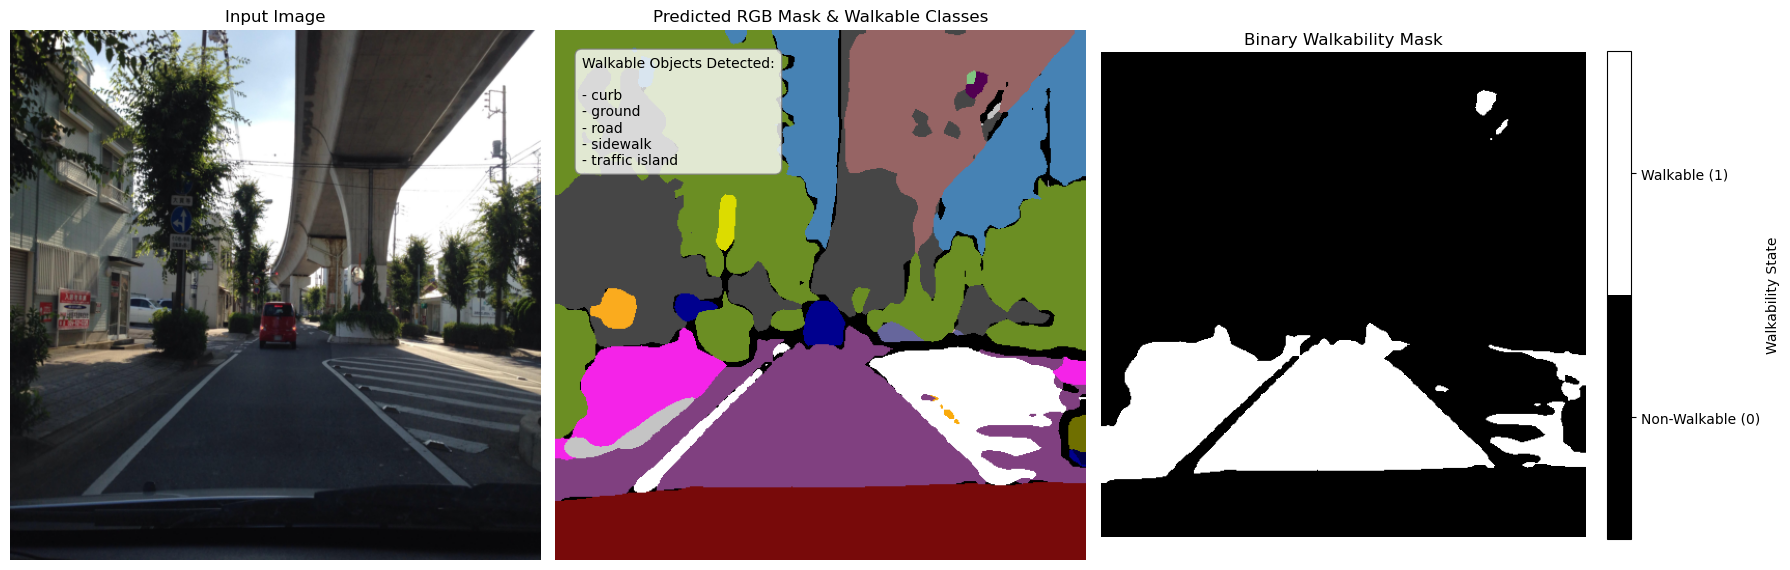

In [12]:
walkability_heatmap = compact_mask_to_walkability(pred_mask, compact_id_to_walkability)

WALKABILITY_THRESHOLD = 0.5 
binary_walkable_mask = (walkability_heatmap > WALKABILITY_THRESHOLD).astype(float) 


cmap_binary = mcolors.ListedColormap(['black', 'white'])
norm_binary = mcolors.Normalize(vmin=0, vmax=1)

# --- Plotting Code ---
# Adjusted figsize back to 18 to fit 3 columns comfortably
plt.figure(figsize=(18,6)) 

# Subplot 1: Input Image
plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

# Subplot 2: Predicted RGB Mask (Now includes the text overlay)
plt.subplot(1,3,2)
plt.title("Predicted RGB Mask & Walkable Classes")
plt.imshow(pred_mask_rgb)
plt.axis('off')

# --- INTEGRATED LEGEND LOGIC (Applied to Subplot 2) ---
title_text = "Walkable Objects Detected:"
list_text = "\n".join([f"- {obj}" for obj in walkable_objects])
display_text = f"{title_text}\n\n{list_text}"

# Display the text in the subplot (using transform=plt.gca().transAxes for position relative to subplot 2)
# Positioned in the top left corner (0.05, 0.95)
plt.text(0.05, 0.95, display_text, 
         transform=plt.gca().transAxes, 
         fontsize=10, 
         verticalalignment='top',
         color='black',
         # Add a background box for readability against the colored mask
         bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8, ec="gray")) 

# Subplot 3: Binary Walkability Mask (Shifted from column 4 to column 3)
plt.subplot(1,3,3)
plt.title("Binary Walkability Mask")
# Use the new binary mask, colormap, and normalization
im = plt.imshow(binary_walkable_mask, cmap=cmap_binary, norm=norm_binary) 
plt.axis('off')

# Customizing the colorbar for a binary mask:
cbar = plt.colorbar(im, ticks=[0.25, 0.75], fraction=0.046, pad=0.04)
# Manually label the ticks for 0 and 1
cbar.ax.set_yticklabels(['Non-Walkable (0)', 'Walkable (1)'])
cbar.set_label("Walkability State")


plt.tight_layout() # Adjust subplots to fit in figure area
plt.show()


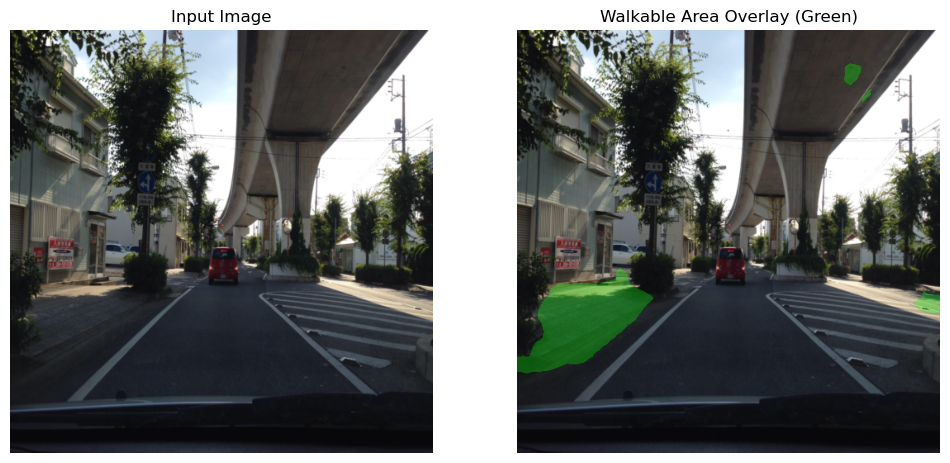

In [58]:
# --- 1. Create the Overlay Image ---
# Get the shape of the image (H, W, 3)
image_arr = np.array(image)
H, W, _ = image_arr.shape

# Initialize a transparent Red mask overlay (H, W, 4) - Red, Green, Blue, Alpha
# We'll use Red for "Walkable" areas.
overlay = np.zeros((H, W, 4))


# RGB fore green (0.0, 1.0, 0.0)
overlay_color = np.array([0.0, 1.0, 0.0]) 
transparency = 0.3 # 50% transparency

# Apply the red color and transparency ONLY where the mask is 1 (walkable)
# The binary_walkable_mask has shape (H, W). We need to tile it to (H, W, 3) for RGB and then add the alpha channel.

# Set RGB channels: Red only for walkable areas
overlay[..., :3] = overlay_color * binary_walkable_mask[..., np.newaxis] 

# Set Alpha channel: Apply transparency ONLY where the mask is 1
overlay[..., 3] = binary_walkable_mask * transparency 

# --- 2. Plotting the Overlay ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Walkable Area Overlay (Green)")
# Display the original image first
plt.imshow(image) 
# Then display the transparent overlay on top
plt.imshow(overlay) 
plt.axis('off')

plt.show()

REAL LIFE TESTING

In [59]:
sample_filename = os.listdir(REAL_IMGS)[1] 

# Load image
image_path = os.path.join(REAL_IMGS, sample_filename)
image = Image.open(image_path).convert("RGB")

# Resize if needed (match your model input size)
transform = T.Resize((512, 512))
image = transform(image)

# Convert image to tensor
image_tensor = T.ToTensor()(image).unsqueeze(0).to(device)  # Add batch dimension

# Run model prediction
model.eval()
with torch.no_grad():
    output = model(image_tensor)["out"]
    pred_mask = output.argmax(dim=1).cpu().numpy()[0]  # shape: (H, W)

pred_mask_rgb = id_mask_to_rgb(pred_mask, compact_id_to_color)

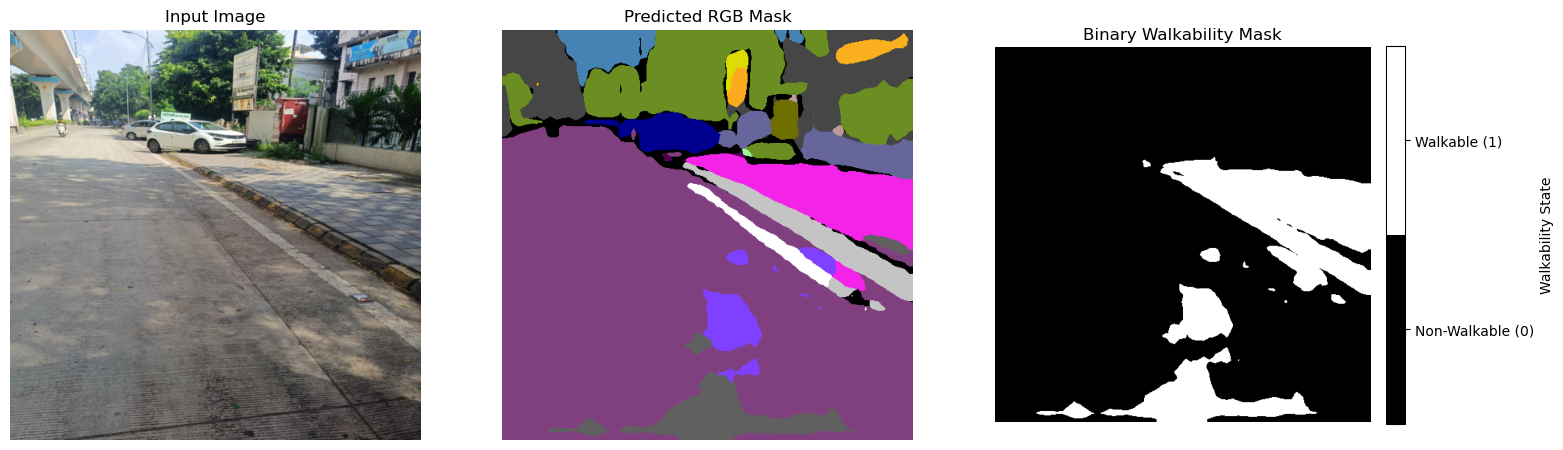

In [60]:
walkability_heatmap = compact_mask_to_walkability(pred_mask, compact_id_to_walkability)

WALKABILITY_THRESHOLD = 0.5 
binary_walkable_mask = (walkability_heatmap > WALKABILITY_THRESHOLD).astype(float) 


cmap_binary = mcolors.ListedColormap(['black', 'white'])
norm_binary = mcolors.Normalize(vmin=0, vmax=1)

# --- Plotting Code ---
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Predicted RGB Mask")
plt.imshow(pred_mask_rgb)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Binary Walkability Mask")
# Use the new binary mask, colormap, and normalization
im = plt.imshow(binary_walkable_mask, cmap=cmap_binary, norm=norm_binary) 
plt.axis('off')

# Customizing the colorbar for a binary mask:
cbar = plt.colorbar(im, ticks=[0.25, 0.75], fraction=0.046, pad=0.04)
# Manually label the ticks for 0 and 1
cbar.ax.set_yticklabels(['Non-Walkable (0)', 'Walkable (1)'])
cbar.set_label("Walkability State")

plt.show()

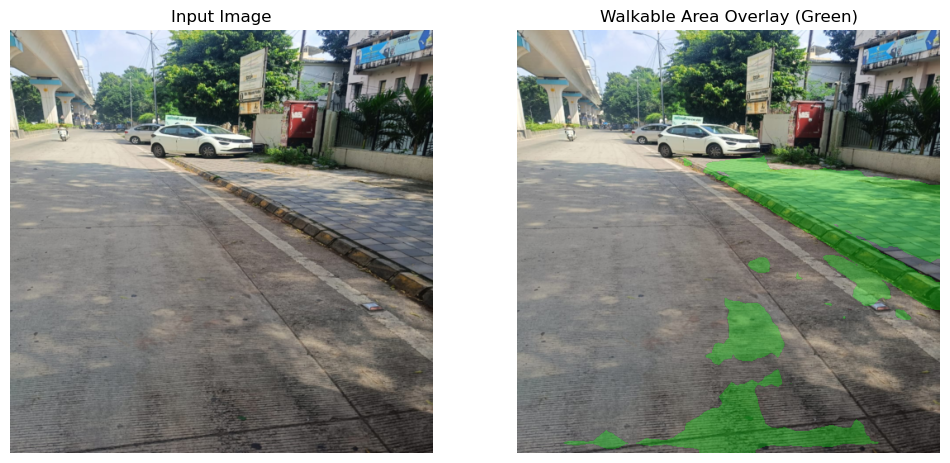

In [61]:
# --- 1. Create the Overlay Image ---
# Get the shape of the image (H, W, 3)
image_arr = np.array(image)
H, W, _ = image_arr.shape

# Initialize a transparent Red mask overlay (H, W, 4) - Red, Green, Blue, Alpha
# We'll use Red for "Walkable" areas.
overlay = np.zeros((H, W, 4))


# RGB fore green (0.0, 1.0, 0.0)
overlay_color = np.array([0.0, 1.0, 0.0]) 
transparency = 0.3 # 50% transparency

# Apply the red color and transparency ONLY where the mask is 1 (walkable)
# The binary_walkable_mask has shape (H, W). We need to tile it to (H, W, 3) for RGB and then add the alpha channel.

# Set RGB channels: Red only for walkable areas
overlay[..., :3] = overlay_color * binary_walkable_mask[..., np.newaxis] 

# Set Alpha channel: Apply transparency ONLY where the mask is 1
overlay[..., 3] = binary_walkable_mask * transparency 

# --- 2. Plotting the Overlay ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Input Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Walkable Area Overlay (Green)")
# Display the original image first
plt.imshow(image) 
# Then display the transparent overlay on top
plt.imshow(overlay) 
plt.axis('off')

plt.show()

In [62]:

import numpy as np
import torch
from torchvision import transforms as T
from PIL import Image

# --- CONFIGURATION ---
# Skip every 3rd frame (process 1, skip 2). Adjust this based on your performance.
FRAME_SKIP = 3 
# Walkability threshold (must match previous steps)
WALKABILITY_THRESHOLD = 0.5 
# The input size your model expects (must match T.Resize in your original code)
MODEL_INPUT_SIZE = (512, 512) 

# Assuming your model is already loaded and on the correct device 'device'
model.eval() 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --- END CONFIGURATION ---

# Define the image transformations (resize, to tensor)
transform = T.Compose([
    T.Resize(MODEL_INPUT_SIZE), 
    T.ToTensor(),
])

In [67]:
import pyttsx3 as pytts
import pyttsx3, pywintypes, pythoncom
import threading

# Initialize text-to-speech engine
engine = pytts.init()
engine.setProperty('rate', 160)   # Speaking rate (can tune)
engine.setProperty('volume', 1.0) # Max volume

def draw_direction_arrow(frame, direction):
    """Draws an arrow symbol or text on the frame based on navigation direction."""
    H, W, _ = frame.shape
    center_x, center_y = W // 2, H - 50  # bottom-center position

    # Define symbol and color (ASCII-safe)
    arrows = {
        "forward": ("FWD", (0, 255, 0)),      # green
        "left": ("LEFT", (255, 255, 0)),      # cyan/yellowish
        "right": ("RIGHT", (0, 255, 255)),    # yellow
        "stop": ("STOP", (0, 0, 255))         # red
    }
    symbol, color = arrows.get(direction, ("?", (255, 255, 255)))

    # Draw black background circle
    cv2.circle(frame, (center_x, center_y), 35, (0, 0, 0), -1)

    # Draw text
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(frame, symbol, (center_x - 40, center_y + 10),
                font, 1.2, color, 3, cv2.LINE_AA)

# Keep track of last direction + last time we spoke
last_direction = None
last_spoken_time = 0
SPEAK_DELAY = 0.8  # seconds between audio prompts

def speak_direction(direction):
    """Speaks asynchronously and safely inside OpenCV loop on Windows."""
    def _speak():
        try:
            pythoncom.CoInitialize()
            engine = pyttsx3.init(driverName='sapi5')  # explicit Windows driver
            engine.setProperty('rate', 120 )
            engine.setProperty('volume', 1.0)

            phrases = {
                "forward": "forward.",
                "left": "left.",
                "right": "right.",
                "stop": "Stop."
            }
            engine.say(phrases[direction])
            engine.runAndWait()
            engine.stop()
            pythoncom.CoUninitialize()
        except Exception as e:
            print("Speech error:", e)

    # run in separate thread so OpenCV loop never blocks
    threading.Thread(target=_speak, daemon=True).start()

# def get_direction(binary_mask):
#     """Analyze walkable mask to determine navigation direction."""
#     H, W = binary_mask.shape
#     bottom_half = binary_mask[H//2:, :]       # near field (closer to user)
#     left_half = bottom_half[:, :W//2]
#     right_half = bottom_half[:, W//2:]

#     # Compute ratios of walkable area
#     left_ratio = np.sum(left_half) / left_half.size
#     right_ratio = np.sum(right_half) / right_half.size
#     bottom_ratio = np.sum(bottom_half) / bottom_half.size
#     full_ratio = np.sum(binary_mask) / binary_mask.size  # overall walkable area

#     # Thresholds (tunable based on real-world conditions)
#     MIN_WALKABLE = 0.02   # at least 2% near bottom area to be considered valid
#     FULL_WALKABLE = 0.7   # if more than 70% of the entire frame is walkable

#     # If almost entire frame is walkable → just go forward
#     if full_ratio >= FULL_WALKABLE:
#         return "forward"

#     # Decide direction based on near-field walkable balance
#     if bottom_ratio < MIN_WALKABLE:
#         return "stop"
#     elif left_ratio > right_ratio * 1.2:
#         return "left"
#     elif right_ratio > left_ratio * 1.2:
#         return "right"
#     else:
#         return "forward"

def get_direction(binary_mask):
    """Improved navigation logic:
       Combines centroid detection + nearest walkable path guidance."""
    H, W = binary_mask.shape

    # --- 1️⃣ Perspective weighting (closer pixels weigh more) ---
    weighted_mask = binary_mask.copy()
    for i in range(H):
        weight = (i / H) ** 2
        weighted_mask[i, :] *= weight

    # --- 2️⃣ Compute walkable coverage ---
    full_ratio = np.sum(weighted_mask) / weighted_mask.size
    MIN_WALKABLE = 0.02
    FULL_WALKABLE = 0.7

    # --- 3️⃣ Centroid calculation ---
    ys, xs = np.nonzero(weighted_mask)
    if len(xs) == 0 or full_ratio < MIN_WALKABLE:
        return "stop"

    cx = np.mean(xs)
    cy = np.mean(ys)
    frame_center = W / 2
    deviation = (cx - frame_center) / frame_center

    # If everything is walkable → move forward
    if full_ratio >= FULL_WALKABLE:
        return "forward"

    # --- 4️⃣ Near-bottom safety check (is there path right ahead?) ---
    near_bottom = weighted_mask[int(H * 0.75):, :]
    bottom_center_strip = near_bottom[:, int(W * 0.4):int(W * 0.6)]
    center_density = np.sum(bottom_center_strip) / bottom_center_strip.size

    if center_density < 0.005:
        # --- 5️⃣ Search for nearest walkable zone horizontally ---
        column_sums = np.sum(near_bottom, axis=0)
        if np.max(column_sums) == 0:
            return "stop"

        nearest_x = np.argmax(column_sums)
        deviation = (nearest_x - frame_center) / frame_center

        if deviation < -0.1:
            return "left"
        elif deviation > 0.1:
            return "right"
        else:
            return "forward"

    # --- 6️⃣ Normal centroid-based direction (path visible ahead) ---
    LEFT_THRESHOLD = -0.15
    RIGHT_THRESHOLD = 0.15
    if deviation < LEFT_THRESHOLD:
        return "left"
    elif deviation > RIGHT_THRESHOLD:
        return "right"
    else:
        return "forward"

# Use 0 for webcam or 'path/to/video.mp4' for a file
VIDEO_NAME = os.listdir(REAL_VIDS)[2]
VIDEO_PATH = os.path.join(REAL_VIDS, VIDEO_NAME)
cap = cv2.VideoCapture(VIDEO_PATH) 

if not cap.isOpened():
    print("Error: Could not open video stream.")
    exit()

# Initialize a frame counter and variables to hold the mask/overlay
frame_counter = 0
last_binary_mask = None
print("Starting real-time walkability segmentation...")

while cap.isOpened():
    ret, frame_cv2 = cap.read() # frame_cv2 is a NumPy array (BGR)
    
    if not ret:
        break

    # --- Frame Skipping Logic ---
    if frame_counter % FRAME_SKIP == 0:
        # Process this frame (only runs once every FRAME_SKIP frames)
        
        # 1. Convert BGR (OpenCV default) to RGB, then to PIL Image
        frame_rgb = cv2.cvtColor(frame_cv2, cv2.COLOR_BGR2RGB)
        image_pil = Image.fromarray(frame_rgb)
        
        # 2. Apply transformations and move to device
        image_tensor = transform(image_pil).unsqueeze(0).to(device)

        # 3. Model Prediction
        with torch.no_grad():
            output = model(image_tensor)["out"]
            pred_mask = output.argmax(dim=1).cpu().numpy()[0] # (H, W) mask
        
        # 4. Mask Processing
        walkability_heatmap = compact_mask_to_walkability(pred_mask, compact_id_to_walkability)
        binary_walkable_mask = (walkability_heatmap > WALKABILITY_THRESHOLD).astype(float) 
        walkable_objects = get_walkable_titles_from_mask(pred_mask, compact_id_to_walkability, compact_id_to_title)
        
        # --- AUDIO GUIDANCE SECTION ---
        current_time = time.time()
        direction = get_direction(binary_walkable_mask)

        # Speak only if direction changed or enough time has passed
        if (direction != last_direction) or (current_time - last_spoken_time > SPEAK_DELAY):
            speak_direction(direction)
            last_direction = direction
            last_spoken_time = current_time

            # Store current direction for visual arrow display
        last_direction = direction

        # 5. Create Overlay
        H, W = binary_walkable_mask.shape
        overlay = np.zeros((H, W, 4))
        
        # Red color overlay configuration
        overlay_color = np.array([0.0, 1.0, 0.0]) 
        transparency = 0.5 
        
        overlay[..., :3] = overlay_color * binary_walkable_mask[..., np.newaxis] 
        overlay[..., 3] = binary_walkable_mask * transparency 

        # Store the current overlay for use in skipped frames
        last_overlay = overlay 

        # Store the formatted text for display
        list_items = "\n".join([f"- {obj}" for obj in walkable_objects])
        last_walkable_objects_text = f"WALKABLE AREAS:\n{list_items}"
    
    else:
        # --- Skipped Frame Logic ---
        # Use the mask calculated from the last processed frame
        if last_overlay is None:
             # If it's the very first skipped frame, just skip the overlay part
             frame_counter += 1
             continue
        
        # Set the current overlay to the last calculated one
        overlay = last_overlay

    # --- 4. Visualization (Applies to all frames, skipped or processed) ---
    
    # Resize the raw OpenCV frame to match the mask size (512x512)
    display_size = (overlay.shape[1], overlay.shape[0]) # (W, H)
    display_image_rgb = cv2.cvtColor(cv2.resize(frame_cv2, display_size), cv2.COLOR_BGR2RGB)
    
    # Convert overlay (float 0-1) to 3-channel RGB (uint8 0-255) for blending
    overlay_rgb_uint8 = (overlay[..., :3] * 255).astype(np.uint8) 
    
    # Blend the overlay (Red) onto the displayed image 
    # cv2.addWeighted performs (src1 * alpha + src2 * beta + gamma)
    blended_frame = cv2.addWeighted(display_image_rgb, 
                                    1.0 - transparency, # Base image weight
                                    overlay_rgb_uint8, 
                                    transparency,       # Overlay image weight
                                    0)                  # Gamma correction

    # Convert back to BGR for display (OpenCV native viewer expects BGR)
    blended_frame_bgr = cv2.cvtColor(blended_frame, cv2.COLOR_RGB2BGR)

    # --- ADDED: Draw the Walkable Objects List onto the blended frame ---
    text_lines = last_walkable_objects_text.split('\n')
    x_pos, y_pos = 10, 30 # Starting position for text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_color = (255, 255, 255) # White text
    line_type = 1
    
    for i, line in enumerate(text_lines):
        (text_w, text_h), baseline = cv2.getTextSize(line, font, font_scale, line_type)
        y_current = y_pos + i * (text_h + baseline + 5)
        
        # Draw background rectangle (black, semi-transparent)
        cv2.rectangle(blended_frame_bgr, (x_pos - 5, y_current - text_h - 5), 
                      (x_pos + text_w + 5, y_current + baseline), 
                      (0, 0, 0), -1) 
        
        # Draw the actual text
        cv2.putText(blended_frame_bgr, line, 
                    (x_pos, y_current), 
                    font, font_scale, font_color, line_type)

    if last_direction is not None:
        draw_direction_arrow(blended_frame_bgr, last_direction)

    # Display the resulting frame
    cv2.imshow('Walkability Overlay (Press Q to Exit)', blended_frame_bgr)
    
    # Increment frame counter
    frame_counter += 1
    
    # Break the loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# --- 5. Cleanup ---
cap.release()
cv2.destroyAllWindows()
print("Video processing stopped.")

Starting real-time walkability segmentation...
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Speech error: run loop already started
Video processing stopped.
